# Clothing Detection and Color Analysis

This project detects clothing items using YOLO and analyzes their dominant colors to evaluate outfit color harmony.

## 1. Install and Import Required Libraries

This section installs the required libraries and imports the tools needed for object detection, image processing, and data analysis.

In [2]:
# ==========================================
# 1. Imports
# ==========================================

import os
import glob
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from ultralytics import YOLO

from IPython.display import display, Image

In [3]:
import sys
print(sys.executable)

c:\Users\Alarabya\anaconda3\python.exe


## 2. Download and Prepare the Dataset

In this section, the clothing dataset is downloaded from Roboflow and prepared for YOLO object detection.

In [4]:
# ==========================================
# 2. Project Configuration
# ==========================================

# Main project directory
PROJECT_DIR = Path.cwd()

# Dataset directory
# Change this only if your dataset is stored somewhere else.
DATASET_DIR = PROJECT_DIR / "clothing--1"

# Trained YOLO model
MODEL_PATH = PROJECT_DIR / "best_yolo26l.pt"

# Folder for cropped detected clothing items
CROP_DIR = PROJECT_DIR / "cropped_clothes"

# Create output folder if it does not exist
CROP_DIR.mkdir(parents=True, exist_ok=True)

# Detection confidence threshold
CONF_THRESHOLD = 0.35

# IoU threshold
IOU_THRESHOLD = 0.50

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)
print("Model path:", MODEL_PATH)
print("Crop directory:", CROP_DIR)

Project directory: e:\Esso\Project
Dataset directory: e:\Esso\Project\clothing--1
Model path: e:\Esso\Project\best_yolo26l.pt
Crop directory: e:\Esso\Project\cropped_clothes


In [5]:
# ==========================================
# 3. Check Required Files
# ==========================================

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"YOLO model was not found:\n{MODEL_PATH}\n"
        "Please place best_yolo26l.pt in the project folder."
    )

print("✓ YOLO model found.")

if DATASET_DIR.exists():
    print("✓ Dataset folder found.")
else:
    print("⚠ Dataset folder not found.")
    print("Detection can still run if you provide an image manually.")

✓ YOLO model found.
✓ Dataset folder found.


In [6]:
# ==========================================
# 4. Load Existing Dataset
# ==========================================

from pathlib import Path

# Change this path to the folder that already contains your dataset
DATASET_DIR = Path(
    r"E:\Esso\Project\clothing--1"
)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found:\n{DATASET_DIR}"
    )

# Find data.yaml automatically
yaml_files = list(DATASET_DIR.rglob("data.yaml"))

if not yaml_files:
    raise FileNotFoundError(
        f"data.yaml was not found inside:\n{DATASET_DIR}"
    )

DATA_YAML = yaml_files[0]

print("✓ Dataset loaded successfully")
print("Dataset:", DATASET_DIR)
print("data.yaml:", DATA_YAML)

✓ Dataset loaded successfully
Dataset: E:\Esso\Project\clothing--1
data.yaml: E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\data.yaml


In [7]:
# ==========================================
# 5. Load YOLO Model
# ==========================================

model = YOLO(str(MODEL_PATH))

print("✓ YOLO model loaded successfully.")

✓ YOLO model loaded successfully.


In [8]:
# ==========================================
# 6. Find data.yaml
# ==========================================

yaml_files = list(DATASET_DIR.rglob("data.yaml"))

if not yaml_files:
    raise FileNotFoundError(
        f"No data.yaml file found inside {DATASET_DIR}"
    )

DATA_YAML = yaml_files[0]

print("Using dataset configuration:")
print(DATA_YAML)

Using dataset configuration:
E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\data.yaml


In [9]:
# ==========================================
# 7. Validate YOLO Model
# ==========================================

metrics = model.val(
    data=str(DATA_YAML)
)

print("\n========== Validation Results ==========")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.146  Python-3.13.9 torch-2.14.0+cpu CPU (Intel Core i5-6300U 2.40GHz)
YOLO26l summary (fused): 188 layers, 24,753,450 parameters, 0 gradients, 86.5 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 1.31.0 MB/s, size: 46.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\valid\labels.cache... 536 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 536/536 107.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 15.0s/it 8:2914.8s
                   all        536       2068      0.761      0.788      0.809      0.547
                   bag        301        301      0.719      0.781      0.809      0.461
                 dress        140        140      0.785      0.879      0.904      0.737
                   hat         

In [10]:
# ==========================================
# 6.5 Check Class Imbalance
# ==========================================

from collections import Counter
import yaml

# Load data.yaml
with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

class_names = data_config["names"]

print("========== Class Distribution ==========")

for split in ["train", "valid", "test"]:

    split_path = DATASET_DIR / "clothing.v1-cloth.yolo26" / split / "labels"

    if not split_path.exists():
        print(f"\n{split}: labels folder not found")
        continue

    counter = Counter()

    label_files = list(split_path.glob("*.txt"))

    for label_file in label_files:

        with open(label_file, "r") as f:
            for line in f:

                line = line.strip()

                if not line:
                    continue

                class_id = int(line.split()[0])
                counter[class_id] += 1

    print(f"\n{split.upper()}")

    total = sum(counter.values())

    for class_id, count in sorted(counter.items()):

        percentage = (count / total) * 100 if total else 0

        print(
            f"{class_names[class_id]:12s} "
            f"{count:5d} instances "
            f"({percentage:5.2f}%)"
        )

========== Class Distribution ==========

TRAIN
bag           1008 instances (13.92%)
dress          467 instances ( 6.45%)
hat            240 instances ( 3.31%)
jacket         679 instances ( 9.38%)
pants          440 instances ( 6.08%)
shirt         1304 instances (18.01%)
shoe          1823 instances (25.17%)
shorts         338 instances ( 4.67%)
skirt          639 instances ( 8.82%)
sunglass       304 instances ( 4.20%)

VALID
bag            301 instances (14.56%)
dress          140 instances ( 6.77%)
hat             79 instances ( 3.82%)
jacket         190 instances ( 9.19%)
pants          122 instances ( 5.90%)
shirt          361 instances (17.46%)
shoe           520 instances (25.15%)
shorts         109 instances ( 5.27%)
skirt          162 instances ( 7.83%)
sunglass        84 instances ( 4.06%)

TEST
bag            153 instances (14.96%)
dress           71 instances ( 6.94%)
hat             31 instances ( 3.03%)
jacket          89 instances ( 8.70%)
pants           60 instance

In [11]:
# ==========================================
# 8. Evaluate on Test Set
# ==========================================

test_metrics = model.val(
    data=str(DATA_YAML),
    split="test"
)

print("\n========== Test Results ==========")
print(f"mAP50:     {test_metrics.box.map50:.4f}")
print(f"mAP50-95:  {test_metrics.box.map:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f}")
print(f"Recall:    {test_metrics.box.mr:.4f}")

Ultralytics 8.4.146  Python-3.13.9 torch-2.14.0+cpu CPU (Intel Core i5-6300U 2.40GHz)
YOLO26l summary (fused): 188 layers, 24,753,450 parameters, 0 gradients, 86.5 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 16.720.1 MB/s, size: 37.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\test\labels.cache... 229 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 229/229 40.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 15.6s/it 3:5519.1s
                   all        229        873      0.811      0.799      0.834      0.563
                   bag        133        133      0.775       0.82      0.855      0.481
                 dress         66         66      0.922      0.893      0.952      0.762
                   hat         

In [12]:
# ==========================================
# 9. Optional Model Training
# ==========================================

TRAIN_MODEL = False

if TRAIN_MODEL:

    pretrained_model = YOLO("yolo26l.pt")

    training_results = pretrained_model.train(
        data=str(DATA_YAML),
        epochs=50,
        imgsz=640,
        batch=-1,
        patience=10,
        project="runs/detect",
        name="outfit_detection",
        exist_ok=True
    )

    print("✓ Training completed.")

else:
    print("Training skipped.")
    print("Using existing best_yolo26l.pt model.")

Training skipped.
Using existing best_yolo26l.pt model.


In [13]:
from pathlib import Path

dataset_path = Path(r"E:\Esso\Project\clothing--1")

print("Dataset exists:", dataset_path.exists())

if dataset_path.exists():
    print("\nContents:")
    for item in dataset_path.iterdir():
        print(item.name)

Dataset exists: True

Contents:
clothing.v1-cloth.yolo26
clothing.v1-cloth.yolo26.zip


In [14]:
# ==========================================
# 10. Find Test Images
# ==========================================

from pathlib import Path

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}

# Search for test images anywhere inside the dataset
test_images = [
    p
    for p in DATASET_DIR.rglob("*")
    if p.is_file() and p.suffix in IMAGE_EXTENSIONS
]

test_images = sorted(test_images)

print(f"Found {len(test_images)} test images.")

if not test_images:
    raise FileNotFoundError(
        f"No test images found inside dataset:\n{DATASET_DIR}"
    )

# Show where the images were found
print("\nExample images:")
for img in test_images[:5]:
    print(img)

Found 2643 test images.

Example images:
E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\test\images\100932_jpg.rf.3c4126472ec60ad757af7e378e8c5f5c.jpg
E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\test\images\1025_jpg.rf.c981fd302d1a012e68d0c9665cfdc17e.jpg
E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\test\images\103084_jpg.rf.7165e392aefeb74112d0bc946bdcb4f0.jpg
E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\test\images\103194_jpg.rf.208bde555538ad69d8a0f0d09ce5f2a1.jpg
E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\test\images\103989_jpg.rf.9e045d8dabead822f5410e01aac29666.jpg


In [15]:
# ==========================================
# 11. Run YOLO Detection
# ==========================================

single_image = str(test_images[0])

results = model.predict(
    source=single_image,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    save=True,
    verbose=False
)

result = results[0]

print("Image:", single_image)
print("Detected objects:", len(result.boxes))

Results saved to E:\Esso\Project\runs\detect\predict-2
Image: E:\Esso\Project\clothing--1\clothing.v1-cloth.yolo26\test\images\100932_jpg.rf.3c4126472ec60ad757af7e378e8c5f5c.jpg
Detected objects: 3


## 3. Train or Load the YOLO Model

This section allows us to either train a new YOLO model or load a previously trained model.

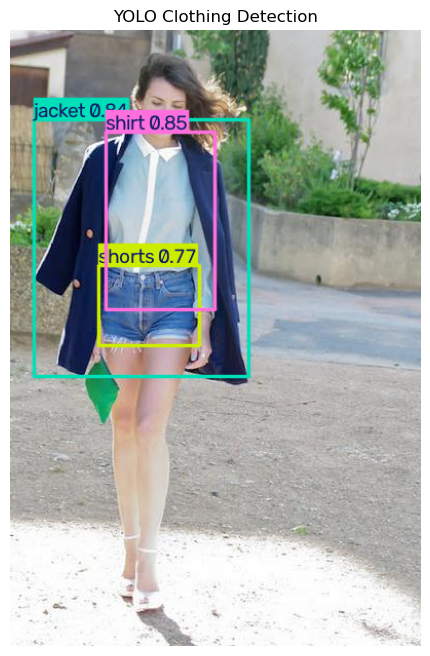

In [16]:
# ==========================================
# 12. Display Detection Result
# ==========================================

annotated_image = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO Clothing Detection")
plt.show()

In [17]:
# ==========================================
# 13. Crop Detected Clothing Items
# ==========================================

def crop_detected_items(
    image_path,
    result,
    output_dir
):
    """
    Crop every detected clothing item from the image.
    Returns a list containing item information.
    """

    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    output_dir = Path(output_dir)
    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    detected_items = []

    for index, box in enumerate(result.boxes):

        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0].tolist()
        )

        confidence = float(
            box.conf[0]
        )

        class_id = int(
            box.cls[0]
        )

        class_name = result.names[class_id]

        # Make sure coordinates stay inside image
        h, w = image.shape[:2]

        x1 = max(0, min(x1, w - 1))
        x2 = max(0, min(x2, w))
        y1 = max(0, min(y1, h - 1))
        y2 = max(0, min(y2, h))

        if x2 <= x1 or y2 <= y1:
            continue

        crop = image[y1:y2, x1:x2]

        output_path = (
            output_dir /
            f"{class_name}_{index}.jpg"
        )

        cv2.imwrite(
            str(output_path),
            crop
        )

        detected_items.append({
            "item": class_name,
            "confidence": confidence,
            "bbox": [x1, y1, x2, y2],
            "crop_path": str(output_path)
        })

    return detected_items

In [18]:
# ==========================================
# 14. Execute Cropping
# ==========================================

# Clear old crop files
for old_file in CROP_DIR.glob("*.jpg"):
    old_file.unlink()

detected_items = crop_detected_items(
    single_image,
    result,
    CROP_DIR
)

print(
    f"✓ Saved {len(detected_items)} cropped clothing items."
)

for item in detected_items:

    print(
        f'{item["item"]} | '
        f'Confidence: {item["confidence"]:.2f} | '
        f'{item["crop_path"]}'
    )

✓ Saved 3 cropped clothing items.
shirt | Confidence: 0.85 | e:\Esso\Project\cropped_clothes\shirt_0.jpg
jacket | Confidence: 0.84 | e:\Esso\Project\cropped_clothes\jacket_1.jpg
shorts | Confidence: 0.77 | e:\Esso\Project\cropped_clothes\shorts_2.jpg


## 4. Model Evaluation

The trained YOLO model is evaluated using validation and test data to measure its detection performance.

In [19]:
# ==========================================
# 15. Fashion Color Palette
# ==========================================

FASHION_COLORS = {

    "Black": (0, 0, 0),
    "White": (255, 255, 255),

    "Dark Gray": (64, 64, 64),
    "Gray": (128, 128, 128),
    "Light Gray": (211, 211, 211),

    "Beige": (245, 245, 220),
    "Cream": (255, 253, 208),
    "Tan": (210, 180, 140),
    "Brown": (101, 67, 33),

    "Red": (220, 20, 60),
    "Burgundy": (128, 0, 32),

    "Pink": (255, 105, 180),
    "Light Pink": (255, 182, 193),
    "Coral": (255, 127, 80),

    "Orange": (255, 165, 0),
    "Yellow": (255, 215, 0),
    "Mustard": (204, 153, 0),

    "Green": (34, 139, 34),
    "Dark Green": (0, 100, 0),
    "Olive": (128, 128, 0),

    "Light Blue": (173, 216, 230),
    "Blue": (70, 130, 180),
    "Navy": (25, 25, 112),
    "Turquoise": (64, 224, 208),

    "Purple": (128, 0, 128),
    "Lavender": (216, 191, 216)
}

NEUTRAL_COLORS = {
    "Black",
    "White",
    "Dark Gray",
    "Gray",
    "Light Gray",
    "Beige",
    "Cream"
}

In [20]:
# ==========================================
# 16. RGB → HSV
# ==========================================

def rgb_to_hsv(rgb):
    """
    Convert RGB color to HSV.

    Hue:
        0-360 degrees

    Saturation:
        0-100%

    Value:
        0-100%
    """

    rgb = np.array(
        rgb,
        dtype=np.uint8
    ).reshape(1, 1, 3)

    hsv = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2HSV
    )[0, 0]

    hue = int(hsv[0]) * 2
    saturation = float(hsv[1]) / 255 * 100
    value = float(hsv[2]) / 255 * 100

    return (
        hue,
        saturation,
        value
    )

In [21]:
# ==========================================
# 17. RGB → Fashion Color Name
# ==========================================

def get_fashion_color_name(rgb):
    """
    Find the closest fashion color using RGB distance.
    """

    rgb = np.array(
        rgb,
        dtype=np.float32
    )

    closest_name = None
    smallest_distance = float("inf")

    for name, reference_rgb in FASHION_COLORS.items():

        reference_rgb = np.array(
            reference_rgb,
            dtype=np.float32
        )

        distance = np.linalg.norm(
            rgb - reference_rgb
        )

        if distance < smallest_distance:

            smallest_distance = distance
            closest_name = name

    return closest_name

In [22]:
# ==========================================
# 18. Extract Dominant Color using K-Means
# ==========================================

def extract_dominant_color(
    image_bgr,
    k=4
):
    """
    Extract the dominant clothing color.

    Steps:
    1. Remove a small border to reduce background influence.
    2. Convert image to RGB.
    3. Apply K-Means clustering.
    4. Select the largest cluster.
    5. Convert RGB to HSV.
    6. Assign a readable fashion color name.
    """

    if image_bgr is None:
        raise ValueError(
            "Input image is empty."
        )

    h, w = image_bgr.shape[:2]

    # Remove 10% border
    margin_x = int(w * 0.10)
    margin_y = int(h * 0.10)

    if (
        w > 20 and
        h > 20
    ):
        image_bgr = image_bgr[
            margin_y:h-margin_y,
            margin_x:w-margin_x
        ]

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    pixels = image_rgb.reshape(
        -1,
        3
    ).astype(np.float32)

    # Prevent K from being larger than number of pixels
    k = min(k, len(pixels))

    if k < 1:
        raise ValueError(
            "Not enough pixels for color analysis."
        )

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        pixels
    )

    centers = kmeans.cluster_centers_

    counts = np.bincount(
        labels
    )

    dominant_index = np.argmax(
        counts
    )

    dominant_rgb = np.clip(
        centers[dominant_index],
        0,
        255
    ).astype(np.uint8)

    percentage = (
        counts[dominant_index] /
        counts.sum()
    ) * 100

    dominant_hsv = rgb_to_hsv(
        dominant_rgb
    )

    color_name = get_fashion_color_name(
        dominant_rgb
    )

    return {
        "rgb": tuple(
            map(int, dominant_rgb)
        ),
        "hsv": dominant_hsv,
        "color_name": color_name,
        "percentage": float(percentage)
    }

In [23]:
# ==========================================
# 19. Analyze All Detected Clothing Items
# ==========================================

analyzed_outfit = []

for item in detected_items:

    crop_path = item["crop_path"]

    crop = cv2.imread(
        crop_path
    )

    color_result = extract_dominant_color(
        crop,
        k=4
    )

    analyzed_item = {
        "item": item["item"],
        "confidence": item["confidence"],
        "bbox": item["bbox"],
        "crop_path": crop_path,

        "rgb": color_result["rgb"],
        "hsv": color_result["hsv"],
        "color_name": color_result["color_name"],
        "color_percentage": color_result["percentage"]
    }

    analyzed_outfit.append(
        analyzed_item
    )

    print(
        f'{item["item"]}: '
        f'{color_result["color_name"]} | '
        f'RGB={color_result["rgb"]} | '
        f'HSV={tuple(round(x, 2) for x in color_result["hsv"])} | '
        f'Dominance={color_result["percentage"]:.1f}%'
    )

shirt: Light Blue | RGB=(176, 199, 213) | HSV=(202, 17.25, 83.53) | Dominance=56.1%
jacket: Navy | RGB=(20, 32, 69) | HSV=(226, 70.98, 27.06) | Dominance=34.1%
shorts: Blue | RGB=(65, 105, 161) | HSV=(216, 59.61, 63.14) | Dominance=50.6%


## 5. Test Object Detection on an Image

A sample test image is selected and passed through the YOLO model to detect clothing items.

In [24]:
# ==========================================
# 20. Hue Difference
# ==========================================

def hue_difference(h1, h2):
    """
    Calculate the shortest angular distance
    between two hues on a 360-degree color wheel.
    """

    difference = abs(
        h1 - h2
    )

    return min(
        difference,
        360 - difference
    )

In [25]:
# ==========================================
# 21. Color Harmony Analysis
# ==========================================

def analyze_color_harmony(
    outfit_items
):
    """
    Determine the dominant color harmony
    of the detected outfit.
    """

    if not outfit_items:
        return "No Colors Detected"

    chromatic_items = [
        item
        for item in outfit_items
        if item["color_name"]
        not in NEUTRAL_COLORS
    ]

    neutral_items = [
        item
        for item in outfit_items
        if item["color_name"]
        in NEUTRAL_COLORS
    ]

    # All neutral
    if len(chromatic_items) == 0:

        return "Neutral Harmony"

    # Only one chromatic color
    if len(chromatic_items) == 1:

        if neutral_items:
            return "Neutral-Based Harmony"

        return "Single Color"

    hues = [
        item["hsv"][0]
        for item in chromatic_items
    ]

    # Two colors
    if len(hues) == 2:

        difference = hue_difference(
            hues[0],
            hues[1]
        )

        if difference <= 15:
            return "Monochromatic"

        if difference <= 45:
            return "Analogous"

        if difference >= 150:
            return "Complementary"

        return "No Standard Harmony"

    # Three or more colors
    hues = hues[:3]

    sorted_hues = sorted(hues)

    d1 = sorted_hues[1] - sorted_hues[0]
    d2 = sorted_hues[2] - sorted_hues[1]
    d3 = 360 - (
        sorted_hues[2] -
        sorted_hues[0]
    )

    # Monochromatic
    if max(
        hue_difference(hues[i], hues[j])
        for i in range(len(hues))
        for j in range(i + 1, len(hues))
    ) <= 15:

        return "Monochromatic"

    # Analogous
    if max(d1, d2, d3) <= 60:

        return "Analogous"

    # Triadic
    if all(
        abs(d - 120) <= 20
        for d in [d1, d2, d3]
    ):

        return "Triadic"

    # Complementary-based
    if any(
        difference >= 150
        for difference in [
            hue_difference(hues[0], hues[1]),
            hue_difference(hues[0], hues[2]),
            hue_difference(hues[1], hues[2])
        ]
    ):

        return "Complementary-Based Harmony"

    return "No Standard Harmony"

In [26]:
# ==========================================
# 22. Color Harmony Score
# ==========================================

HARMONY_SCORES = {

    "Neutral Harmony": 9.0,

    "Neutral-Based Harmony": 9.0,

    "Single Color": 7.5,

    "Monochromatic": 9.0,

    "Analogous": 8.5,

    "Complementary": 9.0,

    "Triadic": 8.5,

    "Complementary-Based Harmony": 8.0,

    "No Standard Harmony": 5.0,

    "No Colors Detected": 0.0
}


def get_color_score(harmony):

    return HARMONY_SCORES.get(
        harmony,
        5.0
    )

In [27]:
# ==========================================
# 21. Color Harmony Analysis
# ==========================================

def hue_difference(h1, h2):
    """
    Calculate the smallest circular difference
    between two Hue values in degrees (0-360).
    """
    diff = abs(h1 - h2)
    return min(diff, 360 - diff)


def analyze_color_harmony(outfit_items):
    """
    Analyze the color harmony of detected clothing items.
    """

    if not outfit_items:
        return "No Colors"

    # ------------------------------------------
    # Separate neutral and chromatic colors
    # ------------------------------------------

    neutral_items = []
    chromatic_items = []

    for item in outfit_items:

        hsv = item["hsv"]
        saturation = hsv[1]
        value = hsv[2]

        # Neutral colors
        if saturation < 0.20 or value < 0.15:
            neutral_items.append(item)

        else:
            chromatic_items.append(item)

    # ------------------------------------------
    # Only neutral colors
    # ------------------------------------------

    if len(chromatic_items) == 0:

        if len(neutral_items) >= 2:
            return "Neutral"

        return "Single Color"

    # ------------------------------------------
    # Only one chromatic color
    # ------------------------------------------

    if len(chromatic_items) == 1:

        if neutral_items:
            return "Neutral-Based Harmony"

        return "Single Color"

    # ------------------------------------------
    # Extract Hue values
    # ------------------------------------------

    hues = [
        item["hsv"][0]
        for item in chromatic_items
    ]

    # ------------------------------------------
    # Two chromatic colors
    # ------------------------------------------

    if len(hues) == 2:

        diff = hue_difference(
            hues[0],
            hues[1]
        )

        # Monochromatic
        if diff <= 15:
            return "Monochromatic"

        # Analogous
        elif diff <= 60:
            return "Analogous"

        # Complementary
        elif diff >= 150:
            return "Complementary"

        else:
            return "No Standard Harmony"

    # ------------------------------------------
    # Three or more chromatic colors
    # ------------------------------------------

    sorted_hues = sorted(hues)

    # Pairwise differences
    pairwise_diffs = [
        hue_difference(hues[i], hues[j])
        for i in range(len(hues))
        for j in range(i + 1, len(hues))
    ]

    # Monochromatic
    if max(pairwise_diffs) <= 15:
        return "Monochromatic"

    # Analogous
    if max(pairwise_diffs) <= 60:
        return "Analogous"

    # ------------------------------------------
    # Triadic
    # ------------------------------------------

    # Use first 3 dominant chromatic colors
    first_three = sorted_hues[:3]

    d1 = first_three[1] - first_three[0]
    d2 = first_three[2] - first_three[1]
    d3 = 360 - (first_three[2] - first_three[0])

    if all(
        abs(d - 120) <= 20
        for d in [d1, d2, d3]
    ):
        return "Triadic"

    # ------------------------------------------
    # Complementary-Based Harmony
    # ------------------------------------------

    if any(
        diff >= 150
        for diff in pairwise_diffs
    ):
        return "Complementary-Based Harmony"

    # ------------------------------------------
    # No standard harmony
    # ------------------------------------------

    return "No Standard Harmony"

In [28]:
# ==========================================
# 24. Results Table
# ==========================================

results_df = pd.DataFrame([
    {
        "Item": item["item"],
        "Confidence": round(
            item["confidence"],
            2
        ),
        "Color": item["color_name"],
        "RGB": item["rgb"],
        "Hue": round(
            item["hsv"][0],
            1
        ),
        "Saturation": round(
            item["hsv"][1],
            1
        ),
        "Value": round(
            item["hsv"][2],
            1
        ),
        "Dominance %": round(
            item["color_percentage"],
            1
        )
    }
    for item in analyzed_outfit
])

results_df

,Item,Confidence,Color,RGB,Hue,Saturation,Value,Dominance %
0,shirt,0.85,Light Blue,"(176, 199, 213)",202,17.3,83.5,56.1
1,jacket,0.84,Navy,"(20, 32, 69)",226,71.0,27.1,34.1
2,shorts,0.77,Blue,"(65, 105, 161)",216,59.6,63.1,50.6
